# Preprocessing Pipeline — SBA National Loan Dataset

This notebook prepares the raw SBA data for model training through the following steps:
1. **Missing value analysis** — classify as MCAR / MAR / MNAR and handle appropriately
2. **Feature engineering** — create new informative columns
3. **Weight of Evidence (WoE) & Information Value (IV)** — score and encode features
4. **Multicollinearity & VIF analysis** — remove redundant features
5. **Train/test split** — export a clean, model-ready dataset

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

# Load raw data
df = pd.read_csv("../data/SBAnational.csv", low_memory=False)

# Parse currency columns immediately
currency_cols = ["DisbursementGross", "BalanceGross", "ChgOffPrinGr", "GrAppv", "SBA_Appv"]
for col in currency_cols:
    df[col] = (
        df[col].astype(str)
        .str.replace(r"[\$,\s]", "", regex=True)
        .pipe(pd.to_numeric, errors="coerce")
    )

# Clean target variable
df["MIS_Status"] = df["MIS_Status"].str.strip()

print(f"Shape: {df.shape}")
df.head(3)

Shape: (899164, 27)


,LoanNr_ChkDgt,Name,City,State,Zip,Bank,BankState,NAICS,ApprovalDate,ApprovalFY,...,RevLineCr,LowDoc,ChgOffDate,DisbursementDate,DisbursementGross,BalanceGross,MIS_Status,ChgOffPrinGr,GrAppv,SBA_Appv
0,1000014003,ABC HOBBYCRAFT,EVANSVILLE,IN,47711,FIFTH THIRD BANK,OH,451120,28-Feb-97,1997,...,N,Y,NaN,28-Feb-99,60000.0,0.0,P I F,0.0,60000.0,48000.0
1,1000024006,LANDMARK BAR & GRILLE (THE),NEW PARIS,IN,46526,1ST SOURCE BANK,IN,722410,28-Feb-97,1997,...,N,Y,NaN,31-May-97,40000.0,0.0,P I F,0.0,40000.0,32000.0
2,1000034009,"WHITLOCK DDS, TODD M.",BLOOMINGTON,IN,47401,GRANT COUNTY STATE BANK,IN,621210,28-Feb-97,1997,...,N,N,NaN,31-Dec-97,287000.0,0.0,P I F,0.0,287000.0,215250.0


# 1. Missing Value Analysis
# Classify each column's missingness as MCAR, MAR, or MNAR before deciding how to handle it.

In [16]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

# Manually classify each missing column based on domain knowledge
mcar_cols  = ["Name", "City", "BankState"]          # random data entry gaps
mar_cols   = ["NewExist"]                            # missingness related to other columns
mnar_cols  = ["ChgOffDate", "BalanceGross", "ChgOffPrinGr"]  # missingness relates to the value itself

classification = {}
for col in df.columns:
    if col in mcar_cols:  classification[col] = "MCAR"
    elif col in mar_cols: classification[col] = "MAR"
    elif col in mnar_cols:classification[col] = "MNAR"
    else:                 classification[col] = "-"

summary = pd.DataFrame({
    "Missing": missing,
    "% Missing": missing_pct,
    "Type": pd.Series(classification)
})
summary[summary["Missing"] > 0].sort_values("% Missing", ascending=False)

,Missing,% Missing,Type
ChgOffDate,736465,81.91,MNAR
RevLineCr,4528,0.50,-
LowDoc,2582,0.29,-
DisbursementDate,2368,0.26,-
MIS_Status,1997,0.22,-
Bank,1559,0.17,-
BankState,1566,0.17,MCAR
NewExist,136,0.02,MAR
Name,14,0.00,MCAR
City,30,0.00,MCAR


### Handling MNAR columns
- Missingness here IS information — imputing would destroy the signal.
- ChgOffDate is only present when a loan defaulted → derive a binary flag instead.
- BalanceGross and ChgOffPrinGr are 0 when a loan is fully paid → fill with 0.

In [17]:
# MNAR: ChgOffDate — presence means the loan defaulted; absence means it didn't
# Derive a binary flag and then drop the raw date column
df["ChgOff_Flag"] = df["ChgOffDate"].notna().astype(int)
df.drop(columns=["ChgOffDate"], inplace=True)

# MNAR: BalanceGross and ChgOffPrinGr — 0 when fully paid, only populated on default
df["BalanceGross"]   = df["BalanceGross"].fillna(0)
df["ChgOffPrinGr"]   = df["ChgOffPrinGr"].fillna(0)

print("MNAR columns handled.")
print(f"ChgOff_Flag value counts:\n{df['ChgOff_Flag'].value_counts()}")

MNAR columns handled.
ChgOff_Flag value counts:
ChgOff_Flag
0    736465
1    162699
Name: count, dtype: int64


### Handling MAR columns
NewExist missingness may depend on loan type or bank — safe to impute with the mode.

In [18]:
# MAR: NewExist — impute with mode (most common value)
newexist_mode = df["NewExist"].mode()[0]
df["NewExist"] = df["NewExist"].fillna(newexist_mode)
print(f"NewExist imputed with mode: {newexist_mode}")

NewExist imputed with mode: 1.0


### Handling MCAR columns & dropping unlabelled rows
- MCAR columns (Name, City, BankState) are either not useful for modelling or can be dropped/filled.
- Rows without a final MIS_Status are unlabelled — we cannot train on them.

In [19]:
# MCAR: BankState — fill with mode (small % missing, random gaps)
df["BankState"] = df["BankState"].fillna(df["BankState"].mode()[0])

# MCAR: Name, City — not useful as model features; will be dropped in feature engineering
# Drop rows with no loan outcome (unlabelled — cannot be used for supervised learning)
before = len(df)
df = df[df["MIS_Status"].isin(["P I F", "CHGOFF"])].copy()
print(f"Dropped {before - len(df):,} unlabelled rows. Remaining: {len(df):,}")

# Create binary target column
df["Defaulted"] = (df["MIS_Status"] == "CHGOFF").astype(int)
print(f"\nTarget distribution:\n{df['Defaulted'].value_counts()}")

Dropped 1,997 unlabelled rows. Remaining: 897,167

Target distribution:
Defaulted
0    739609
1    157558
Name: count, dtype: int64


---
## 2. Feature Engineering

Create new columns that capture additional signal before encoding and selection.

In [20]:
# --- Date features ---
df["ApprovalDate"]     = pd.to_datetime(df["ApprovalDate"],     errors="coerce", dayfirst=True)
df["DisbursementDate"] = pd.to_datetime(df["DisbursementDate"], errors="coerce", dayfirst=True)

# Days between approval and actual disbursement — long gaps may signal complexity or risk
df["DaysToDisbursement"] = (df["DisbursementDate"] - df["ApprovalDate"]).dt.days.clip(lower=0)

# Month of approval — captures seasonal lending patterns
df["ApprovalMonth"] = df["ApprovalDate"].dt.month

# Drop raw date columns — all signal has been extracted
df.drop(columns=["ApprovalDate", "DisbursementDate"], inplace=True)

# ApprovalFY contains some non-numeric entries like '1976A' — coerce to numeric (bad values become NaN)
df["ApprovalFY"] = pd.to_numeric(df["ApprovalFY"], errors="coerce")

# --- Industry ---
# Use 2-digit NAICS sector code instead of the full 6-digit code (reduces cardinality)
df["NAICS2"] = df["NAICS"].astype(str).str[:2]
df.drop(columns=["NAICS"], inplace=True)

# --- Loan ratio ---
# Proportion of the loan guaranteed by the SBA — higher coverage = more government-backed risk
df["SBA_Coverage"] = (df["SBA_Appv"] / df["GrAppv"]).clip(0, 1)

# --- Binary flags from categorical codes ---
# NewExist: 2 = new business (higher risk), 1 = existing
df["IsNewBusiness"]     = (df["NewExist"] == 2).astype(int)

# FranchiseCode: 1 = not a franchise; any other code = is a franchise
df["IsFranchise"]       = (df["FranchiseCode"] != 1).astype(int)

# UrbanRural: 1 = urban, 2 = rural, 0 = undefined
df["IsUrban"]           = (df["UrbanRural"] == 1).astype(int)
df["IsRural"]           = (df["UrbanRural"] == 2).astype(int)

# RevLineCr / LowDoc: Y/N string flags → binary integers
df["IsRevolvingCredit"] = (df["RevLineCr"].str.strip() == "Y").astype(int)
df["IsLowDoc"]          = (df["LowDoc"].str.strip()    == "Y").astype(int)

# --- Log-transform skewed monetary columns ---
# Reduces the influence of extreme outliers on linear models
for col in ["GrAppv", "SBA_Appv", "DisbursementGross"]:
    df[f"Log_{col}"] = np.log1p(df[col])

print("Feature engineering complete. New columns added:")
new_cols = ["DaysToDisbursement", "ApprovalMonth", "NAICS2", "SBA_Coverage",
            "IsNewBusiness", "IsFranchise", "IsUrban", "IsRural",
            "IsRevolvingCredit", "IsLowDoc", "Log_GrAppv", "Log_SBA_Appv", "Log_DisbursementGross"]
print(new_cols)
print(f"\nApprovalFY non-numeric rows set to NaN: {df['ApprovalFY'].isna().sum()}")

/var/folders/hq/v_7wt_d51sn37zqs9vlsf41c0000gn/T/ipykernel_42557/2204363648.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["ApprovalDate"]     = pd.to_datetime(df["ApprovalDate"],     errors="coerce", dayfirst=True)
/var/folders/hq/v_7wt_d51sn37zqs9vlsf41c0000gn/T/ipykernel_42557/2204363648.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["DisbursementDate"] = pd.to_datetime(df["DisbursementDate"], errors="coerce", dayfirst=True)


Feature engineering complete. New columns added:
['DaysToDisbursement', 'ApprovalMonth', 'NAICS2', 'SBA_Coverage', 'IsNewBusiness', 'IsFranchise', 'IsUrban', 'IsRural', 'IsRevolvingCredit', 'IsLowDoc', 'Log_GrAppv', 'Log_SBA_Appv', 'Log_DisbursementGross']

ApprovalFY non-numeric rows set to NaN: 18


---
## 3. Weight of Evidence (WoE) & Information Value (IV)

**WoE** measures how strongly each category of a feature separates defaulters from non-defaulters:

`WoE = ln( % Non-Events in bin / % Events in bin )`

**IV** summarises the total predictive power of a feature across all its bins:

| IV Range | Predictive Power |
|---|---|
| < 0.02 | Useless — drop |
| 0.02 – 0.1 | Weak |
| 0.1 – 0.3 | Medium |
| 0.3 – 0.5 | Strong |
| > 0.5 | Suspicious — may overfit, review carefully |

In [21]:
def compute_woe_iv(df, feature, target, bins=10, is_categorical=False):
    """
    Compute WoE and IV for a single feature.
    For continuous features, bin into quantile-based buckets.
    For categorical features, group by category directly.
    Returns a DataFrame of WoE per bin and the total IV.
    """
    total_events     = df[target].sum()
    total_nonevents  = len(df) - total_events

    if is_categorical:
        grouped = df.groupby(feature)[target].agg(["sum", "count"])
    else:
        # Use quantile-based bins; duplicates dropped to handle skewed distributions
        df["_bin"] = pd.qcut(df[feature], q=bins, duplicates="drop")
        grouped = df.groupby("_bin")[target].agg(["sum", "count"])
        df.drop(columns=["_bin"], inplace=True)

    grouped.columns = ["Events", "Total"]
    grouped["NonEvents"] = grouped["Total"] - grouped["Events"]

    # Avoid division by zero or log(0) with a small epsilon
    eps = 0.5
    grouped["Pct_Events"]    = (grouped["Events"]    + eps) / (total_events    + eps)
    grouped["Pct_NonEvents"] = (grouped["NonEvents"] + eps) / (total_nonevents + eps)
    grouped["WoE"]           = np.log(grouped["Pct_NonEvents"] / grouped["Pct_Events"])
    grouped["IV_bin"]        = (grouped["Pct_NonEvents"] - grouped["Pct_Events"]) * grouped["WoE"]

    iv = grouped["IV_bin"].sum()
    return grouped[["Events", "NonEvents", "WoE", "IV_bin"]], iv


# Define which features to evaluate and whether they are categorical
features_to_evaluate = {
    # Continuous (will be binned)
    "Term": False, "NoEmp": False, "CreateJob": False, "RetainedJob": False,
    "GrAppv": False, "SBA_Appv": False, "DisbursementGross": False,
    "Log_GrAppv": False, "Log_SBA_Appv": False, "Log_DisbursementGross": False,
    "SBA_Coverage": False, "DaysToDisbursement": False, "ApprovalFY": False,
    "ApprovalMonth": False, "BalanceGross": False, "ChgOffPrinGr": False,
    # Categorical / binary
    "NAICS2": True, "State": True, "BankState": True,
    "IsNewBusiness": True, "IsFranchise": True, "IsUrban": True, "IsRural": True,
    "IsRevolvingCredit": True, "IsLowDoc": True, "ChgOff_Flag": True,
}

iv_results = {}
for feat, is_cat in features_to_evaluate.items():
    try:
        _, iv = compute_woe_iv(df.copy(), feat, "Defaulted", bins=10, is_categorical=is_cat)
        iv_results[feat] = round(iv, 4)
    except Exception as e:
        iv_results[feat] = None

iv_df = (pd.Series(iv_results)
           .reset_index()
           .rename(columns={"index": "Feature", 0: "IV"})
           .sort_values("IV", ascending=False))

# Label predictive strength
def iv_label(iv):
    if iv is None: return "Error"
    if iv < 0.02:  return "Useless"
    if iv < 0.1:   return "Weak"
    if iv < 0.3:   return "Medium"
    if iv < 0.5:   return "Strong"
    return "Suspicious (overfit risk)"

iv_df["Strength"] = iv_df["IV"].apply(iv_label)
iv_df

,Feature,IV,Strength
25,ChgOff_Flag,13.0198,Suspicious (overfit risk)
15,ChgOffPrinGr,3.9708,Suspicious (overfit risk)
0,Term,1.0890,Suspicious (overfit risk)
12,ApprovalFY,0.7738,Suspicious (overfit risk)
10,SBA_Coverage,0.5050,Suspicious (overfit risk)
11,DaysToDisbursement,0.3580,Strong
5,SBA_Appv,0.3512,Strong
8,Log_SBA_Appv,0.3512,Strong
20,IsFranchise,0.2921,Medium
18,BankState,0.2812,Medium


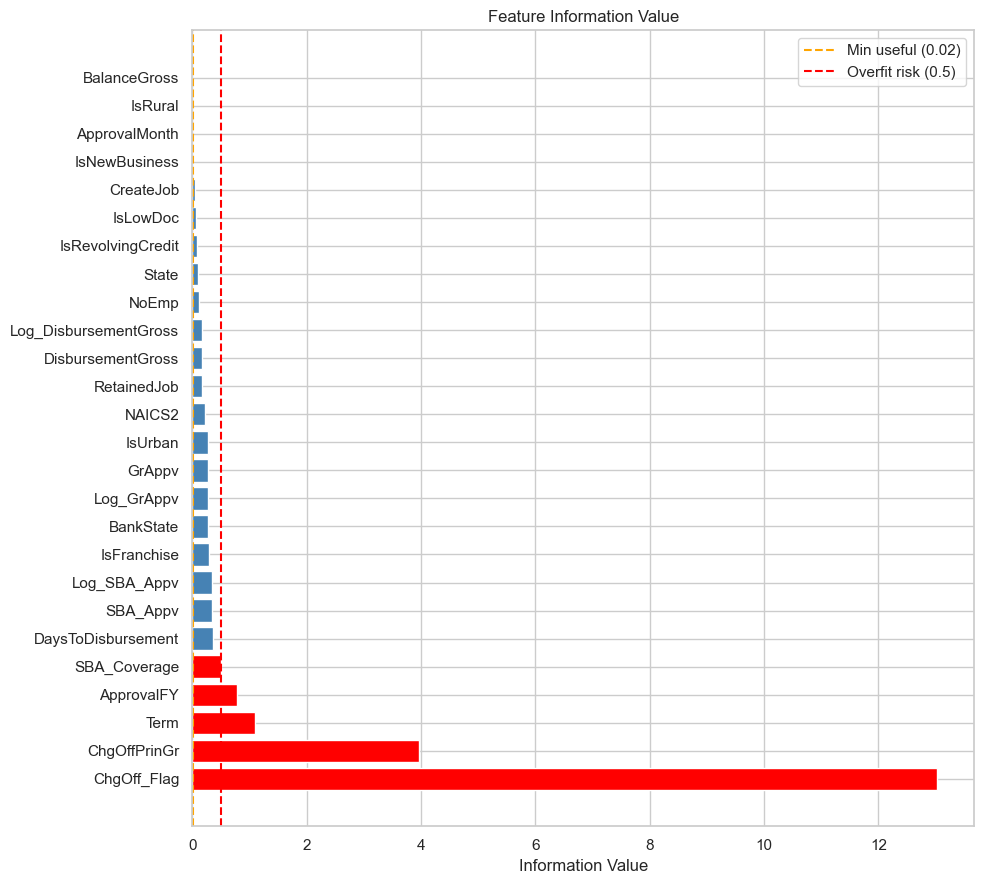

In [22]:
# Visualise IV scores for quick comparison
fig, ax = plt.subplots(figsize=(10, 9))
colors = iv_df["IV"].apply(lambda v: "red" if v > 0.5 else ("steelblue" if v >= 0.02 else "lightgray"))
ax.barh(iv_df["Feature"], iv_df["IV"], color=colors)
ax.axvline(0.02, color="orange", linestyle="--", label="Min useful (0.02)")
ax.axvline(0.5,  color="red",    linestyle="--", label="Overfit risk (0.5)")
ax.set_xlabel("Information Value")
ax.set_title("Feature Information Value")
ax.legend()
plt.tight_layout()
plt.show()

In [23]:
# Drop useless features (IV < 0.02) and suspicious ones (IV > 0.5)
drop_iv = iv_df[(iv_df["IV"] < 0.02) | (iv_df["IV"] > 0.5)]["Feature"].tolist()

# Also drop columns that are identifiers, raw encodings superseded by engineered features,
# or leakage risks (ChgOffPrinGr directly encodes the default outcome)
drop_manual = [
    "LoanNr_ChkDgt",   # identifier — no predictive signal
    "Name",            # free-text business name
    "City",            # too high cardinality, State captures geography
    "Zip",             # too high cardinality
    "Bank",            # too high cardinality
    "MIS_Status",      # raw target — replaced by Defaulted
    "NewExist",        # superseded by IsNewBusiness
    "FranchiseCode",   # superseded by IsFranchise
    "UrbanRural",      # superseded by IsUrban / IsRural
    "RevLineCr",       # superseded by IsRevolvingCredit
    "LowDoc",          # superseded by IsLowDoc
    "ChgOffPrinGr",    # data leakage — only populated after default occurs
    "BalanceGross",    # data leakage — reflects post-outcome balance
    "ChgOff_Flag",     # directly encodes the target — leakage
]

all_drops = list(set(drop_iv + drop_manual))
# Only drop columns that actually exist
all_drops = [c for c in all_drops if c in df.columns]

df.drop(columns=all_drops, inplace=True)
print(f"Dropped {len(all_drops)} columns. Remaining: {df.shape[1]}")
print(f"Remaining columns:\n{df.columns.tolist()}")

Dropped 20 columns. Remaining: 18
Remaining columns:
['State', 'BankState', 'NoEmp', 'CreateJob', 'RetainedJob', 'DisbursementGross', 'GrAppv', 'SBA_Appv', 'Defaulted', 'DaysToDisbursement', 'NAICS2', 'IsFranchise', 'IsUrban', 'IsRevolvingCredit', 'IsLowDoc', 'Log_GrAppv', 'Log_SBA_Appv', 'Log_DisbursementGross']


### WoE Encoding

Replace each categorical feature's raw values with its WoE score.
WoE is fitted on the **training set only** and applied to both train and test to prevent data leakage.

In [24]:
# Categorical columns still in the dataset that need WoE encoding
cat_cols_to_encode = [c for c in ["NAICS2", "State", "BankState"] if c in df.columns]

def fit_woe_map(train_df, feature, target, eps=0.5):
    """Compute WoE for each category and return a mapping dict."""
    total_events    = train_df[target].sum()
    total_nonevents = len(train_df) - total_events
    grouped = train_df.groupby(feature)[target].agg(["sum", "count"])
    grouped.columns = ["Events", "Total"]
    grouped["NonEvents"]     = grouped["Total"] - grouped["Events"]
    grouped["Pct_Events"]    = (grouped["Events"]    + eps) / (total_events    + eps)
    grouped["Pct_NonEvents"] = (grouped["NonEvents"] + eps) / (total_nonevents + eps)
    grouped["WoE"]           = np.log(grouped["Pct_NonEvents"] / grouped["Pct_Events"])
    return grouped["WoE"].to_dict()

# Store WoE maps — fitted later on training set (see Section 5)
# For now, compute on full dataset to inspect the encodings
woe_maps = {}
for col in cat_cols_to_encode:
    woe_maps[col] = fit_woe_map(df, col, "Defaulted")
    df[f"WoE_{col}"] = df[col].map(woe_maps[col]).fillna(0)
    df.drop(columns=[col], inplace=True)
    print(f"WoE encoded: {col}")

print(f"\nDataset shape after WoE encoding: {df.shape}")

WoE encoded: NAICS2
WoE encoded: State
WoE encoded: BankState

Dataset shape after WoE encoding: (897167, 18)


---
## 4. Multicollinearity & VIF Analysis

High correlation between features causes unstable model coefficients and inflated standard errors.  
**VIF (Variance Inflation Factor)** quantifies how much a feature's variance is explained by other features:

- VIF = 1: no correlation
- VIF 1–5: acceptable
- VIF 5–10: moderate — investigate  
- VIF > 10: severe multicollinearity — drop or combine

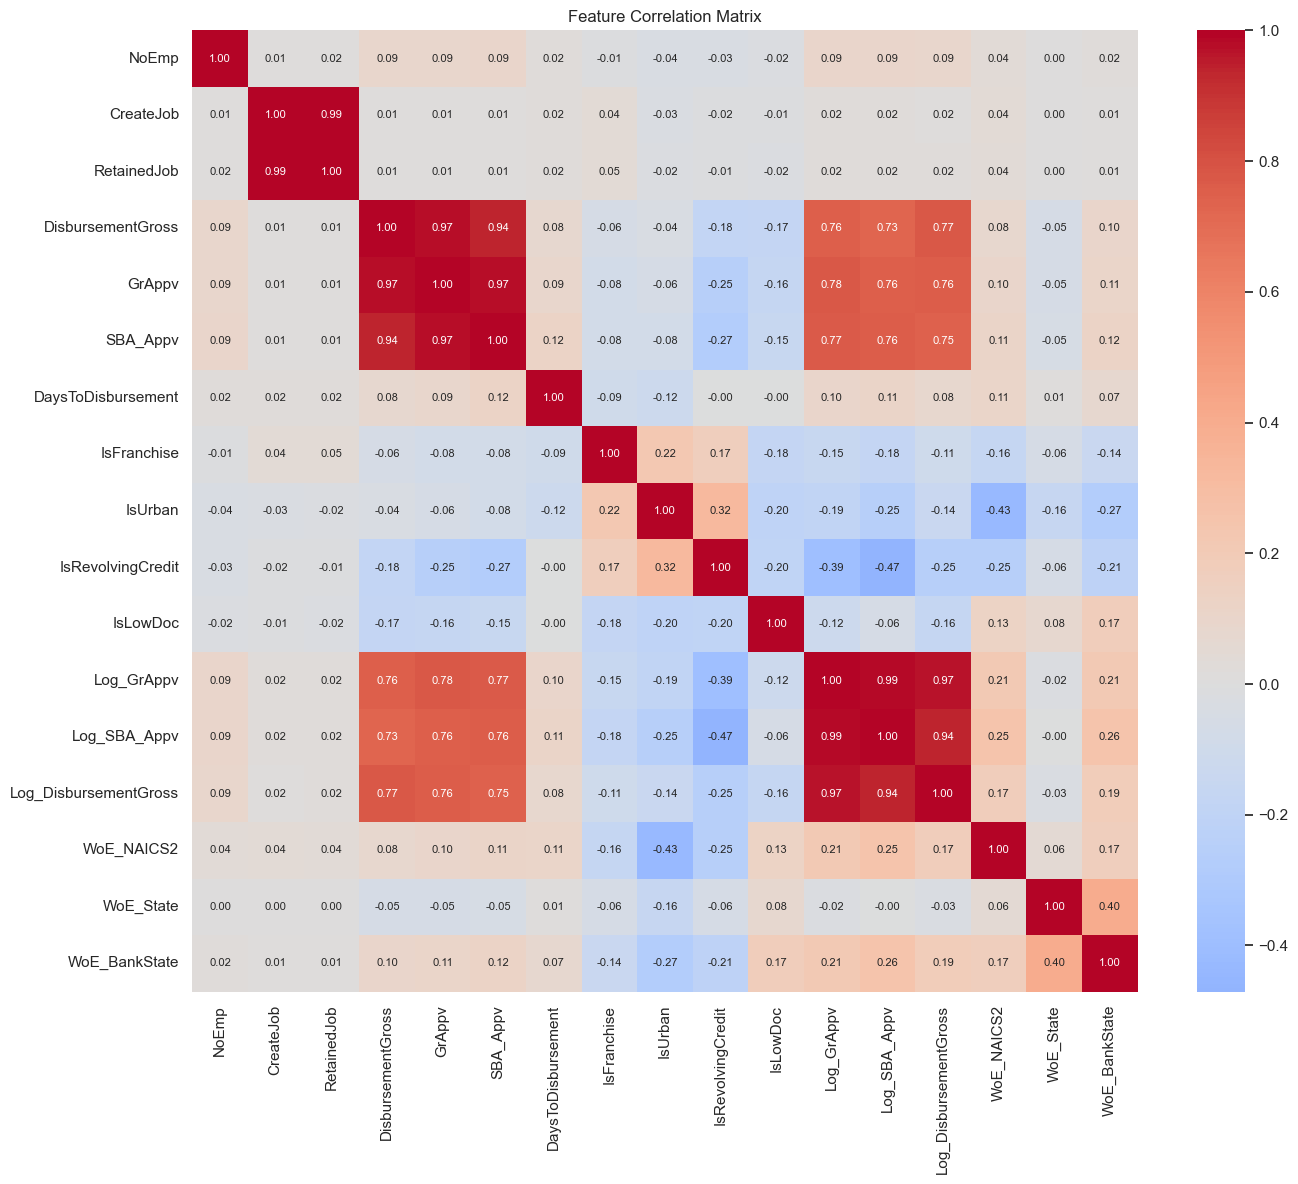

In [25]:
# Correlation heatmap — spot highly correlated pairs before running VIF
feature_cols = [c for c in df.columns if c != "Defaulted"]
corr = df[feature_cols].corr()

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            annot_kws={"size": 8}, ax=ax)
ax.set_title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

In [26]:
def compute_vif(df, feature_cols):
    """Compute VIF for each feature. Drops NaN rows for calculation."""
    X = df[feature_cols].dropna()
    vif_data = pd.DataFrame({
        "Feature": feature_cols,
        "VIF": [variance_inflation_factor(X.values, i) for i in range(len(feature_cols))]
    }).sort_values("VIF", ascending=False)
    return vif_data

vif_df = compute_vif(df, feature_cols)
vif_df

,Feature,VIF
11,Log_GrAppv,8239.146487
12,Log_SBA_Appv,4834.600736
13,Log_DisbursementGross,2721.935670
2,RetainedJob,84.003696
1,CreateJob,83.975991
4,GrAppv,80.016632
5,SBA_Appv,39.078502
3,DisbursementGross,36.923959
8,IsUrban,3.065956
9,IsRevolvingCredit,2.942981


In [27]:
# Iteratively drop the highest VIF feature until all are below threshold
VIF_THRESHOLD = 10

def remove_high_vif(df, feature_cols, threshold=10):
    cols = feature_cols.copy()
    dropped = []
    while True:
        vif = compute_vif(df, cols)
        max_vif = vif["VIF"].max()
        if max_vif <= threshold:
            break
        worst = vif.loc[vif["VIF"].idxmax(), "Feature"]
        print(f"Dropping '{worst}' — VIF: {max_vif:.2f}")
        cols.remove(worst)
        dropped.append(worst)
    print(f"\nDone. Dropped {len(dropped)} features for multicollinearity: {dropped}")
    return cols, dropped

final_features, vif_dropped = remove_high_vif(df, feature_cols, VIF_THRESHOLD)

Dropping 'Log_GrAppv' — VIF: 8239.15
Dropping 'Log_DisbursementGross' — VIF: 1596.69
Dropping 'RetainedJob' — VIF: 83.99
Dropping 'GrAppv' — VIF: 62.37
Dropping 'SBA_Appv' — VIF: 14.13

Done. Dropped 5 features for multicollinearity: ['Log_GrAppv', 'Log_DisbursementGross', 'RetainedJob', 'GrAppv', 'SBA_Appv']


In [28]:
# Final VIF check after removals
vif_final = compute_vif(df, final_features)
print("Final VIF scores (all should be ≤ 10):")
vif_final

Final VIF scores (all should be ≤ 10):


,Feature,VIF
8,Log_SBA_Appv,5.043254
5,IsUrban,2.881976
2,DisbursementGross,1.940507
6,IsRevolvingCredit,1.530973
4,IsFranchise,1.530392
3,DaysToDisbursement,1.436386
11,WoE_BankState,1.371339
9,WoE_NAICS2,1.312539
7,IsLowDoc,1.298979
10,WoE_State,1.215048


---
## 5. Prepare Dataset for Model Training

Split into train/test sets, then save to disk so the modelling notebook can load clean data directly.

In [29]:
# Build final clean dataset using only the features that survived IV and VIF filtering
df_model = df[final_features + ["Defaulted"]].dropna().reset_index(drop=True)

print(f"Final dataset shape: {df_model.shape}")
print(f"Features: {final_features}")
print(f"\nTarget distribution:\n{df_model['Defaulted'].value_counts()}")
print(f"Default rate: {df_model['Defaulted'].mean():.2%}")

Final dataset shape: (894992, 13)
Features: ['NoEmp', 'CreateJob', 'DisbursementGross', 'DaysToDisbursement', 'IsFranchise', 'IsUrban', 'IsRevolvingCredit', 'IsLowDoc', 'Log_SBA_Appv', 'WoE_NAICS2', 'WoE_State', 'WoE_BankState']

Target distribution:
Defaulted
0    737760
1    157232
Name: count, dtype: int64
Default rate: 17.57%


In [30]:
X = df_model[final_features]
y = df_model["Defaulted"]

# Stratified split preserves the ~17% default rate in both train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {X_train.shape[0]:,}  |  Test size: {X_test.shape[0]:,}")
print(f"Train default rate: {y_train.mean():.2%}")
print(f"Test  default rate: {y_test.mean():.2%}")

Train size: 715,993  |  Test size: 178,999
Train default rate: 17.57%
Test  default rate: 17.57%


In [31]:
import os

os.makedirs("../data/processed", exist_ok=True)

# Save train and test sets separately so the modelling notebook loads them directly
X_train.to_csv("../data/processed/X_train.csv", index=False)
X_test.to_csv( "../data/processed/X_test.csv",  index=False)
y_train.to_csv("../data/processed/y_train.csv", index=False)
y_test.to_csv( "../data/processed/y_test.csv",  index=False)

# Also save the full processed dataset for reference
df_model.to_csv("../data/processed/sba_processed.csv", index=False)

print("Saved to ../data/processed/")
print(os.listdir("../data/processed/"))

Saved to ../data/processed/
['sba_processed.csv', 'X_train.csv', 'y_train.csv', 'y_test.csv', 'X_test.csv']
